# Open-Field Behavioral Analysis Using DeepLabCut

This project demonstrates a basic behavioral quantification workflow using DeepLabCut-based pose estimation in an open-field mouse experiment.

The workflow includes:
- Pose extraction from video
- Trajectory visualization
- Distance traveled analysis
- Velocity estimation
- Spatial occupancy heatmap generation

The project was implemented using Python, DeepLabCut, NumPy, pandas, and Matplotlib.

 =========================
# Project Configuration
 =========================

In [ ]:
CSV_FILE   = 'Coordinates.csv'
BODY_PART  = 'Snout'  # body part to track
                          # choices: Snout, Neck, Spine_1, Spine_2,
                          #          Left_ear, Right_ear, R_leg, L_leg,
                          #          Tailbase, tail_1, tail_2, tail_3
FPS        = 30
SIGMA      = 2
VIDEO_W    = 640
VIDEO_H    = 480

# Open-Field Demo Project


Upload the CSV to Colab, run all cells top to bottom.

---

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

### Data Loading and Mapping
In this section, we load the CSV file and parse the multi-level header typical of DeepLabCut output. We map each body part to its corresponding column indices for x, y, and likelihood data.

## 3. Load the CSV

In [86]:
df = pd.read_csv(CSV_FILE)

# Pull body part names and coord types from header rows
body_parts   = df.iloc[0, 1:].values   # e.g. Snout, Snout, Snout, Left_ear...
coord_types = df.iloc[1, 1:].values  # e.g. x, y, likelihood, x, y...

# Build a map: body part name -> column index for x, y, likelihood
bp_map = {}
for i, (bp, coord) in enumerate(zip(body_parts, coord_types)):
    col = i + 1  # offset by 1 because col 0 is the frame number
    if bp not in bp_map:
        bp_map[bp] = {}
    bp_map[bp][coord] = col

# Data rows start at row 3
data = df.iloc[3:, :].reset_index(drop=True)

print(f'Total frames : {len(data)}')
print(f'Session time : {len(data)/FPS:.1f} seconds')
print(f'Body parts   : {list(bp_map.keys())}')

Total frames : 2329
Session time : 77.6 seconds
Body parts   : ['Snout', 'Left_ear', 'Right_ear', 'Spine_1', 'Spine_2', 'R_leg', 'L_leg', 'Neck', 'Tailbase', 'tail_1', 'tail_2', 'tail_3']


In [87]:
# Get x, y, and likelihood for the chosen body part
x_col = bp_map[BODY_PART]['x']
y_col = bp_map[BODY_PART]['y']
l_col = bp_map[BODY_PART]['likelihood']

x  = pd.to_numeric(data.iloc[:, x_col]).values
y  = pd.to_numeric(data.iloc[:, y_col]).values
lk = pd.to_numeric(data.iloc[:, l_col]).values

print(f'X range: {x.min():.1f} -- {x.max():.1f} px')
print(f'Y range: {y.min():.1f} -- {y.max():.1f} px')

X range: 17.3 -- 615.6 px
Y range: 52.5 -- 468.9 px


## Likelihood filtering

In [88]:
LIKELIHOOD_THRESHOLD = 0.4

mask = lk > LIKELIHOOD_THRESHOLD

x = x[mask]
y = y[mask]
lk = lk[mask]

### Trajectory Visualization
Here we visualize the path taken by the mouse. We use a dashed line to show the movement sequence and highlight the start (green) and end (red) points to understand the direction of travel.

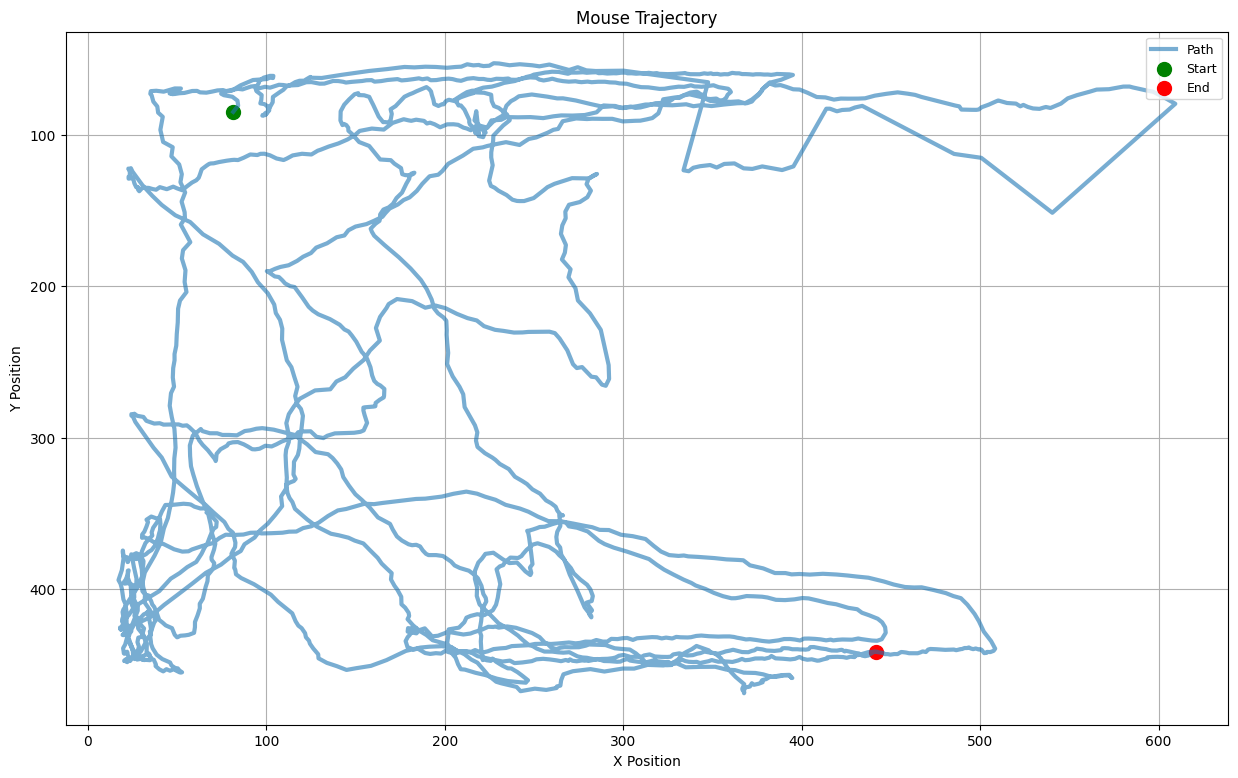

In [89]:
plt.figure(figsize=(15, 9))

plt.plot(x, y, linewidth=3, markersize=8, alpha=0.6, label='Path')
plt.gca().invert_yaxis()
plt.scatter(x[0], y[0], color="green", s=100, label='Start', alpha=1)
plt.scatter(x[-1], y[-1], color="red", s=100, label='End', alpha=1)

plt.title("Mouse Trajectory")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend(fontsize=9, loc='upper right')
plt.grid(True)
plt.show()

## **Distance Traveled**
The calculated distance is expressed in pixels. Arena calibration is required for conversion to physical units such as centimeters.

In [90]:
dx = np.diff(x)
dy = np.diff(y)

distance_per_frame = np.sqrt(dx**2 + dy**2)
total_distance = np.sum(distance_per_frame)

print(f"The total distance traveled by mouse is : {total_distance}")

The total distance traveled by mouse is : 8944.828332066618


### Distance Calculation
This cell calculates the cumulative Euclidean distance traveled across all frames. Note that this value is currently in pixels; physical calibration is required to convert this to centimeters.

## **Advanced Velocity Calculation**
We use a Gaussian filter to smooth the trajectory and filter out tracking jitter before calculating velocity in px/s.

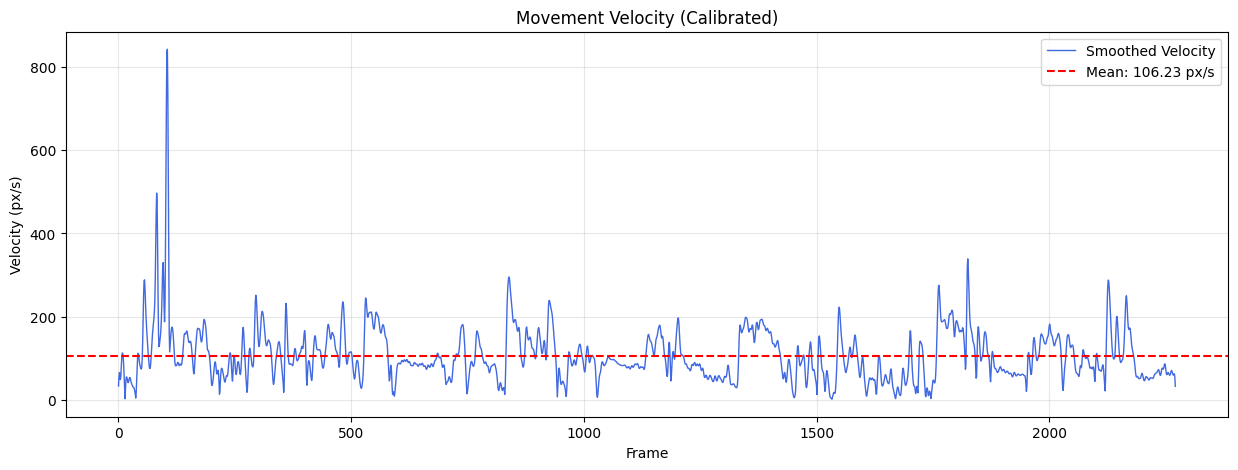

Average Velocity: 106.23 px/s
Peak Velocity: 843.21 px/s


In [91]:
  # Adjust this based on your arena size
SIGMA = 2             # Smoothing factor for Gaussian filter
FPS = 30              # frames per second

# 1. Smooth the coordinates to reduce jitter noise
x_smoothed = gaussian_filter(x, sigma=SIGMA)
y_smoothed = gaussian_filter(y, sigma=SIGMA)

# 2. Calculate displacements on smoothed data
dx_s = np.diff(x_smoothed)
dy_s = np.diff(y_smoothed)

# 3. Calculate velocity (Distance / Time)
# distance (px) = pixels
# time (s) = 1 / FPS
dist_px = np.sqrt(dx_s**2 + dy_s**2)
velocity_px_s = dist_px * FPS

# 4. Plot smoothed velocity
plt.figure(figsize=(15, 5))
plt.plot(velocity_px_s, color='royalblue', linewidth=1, label='Smoothed Velocity')
plt.axhline(y=np.mean(velocity_px_s), color='red', linestyle='--', label=f'Mean: {np.mean(velocity_px_s):.2f} px/s')

plt.title("Movement Velocity (Calibrated)")
plt.xlabel("Frame")
plt.ylabel("Velocity (px/s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average Velocity: {np.mean(velocity_px_s):.2f} px/s")
print(f"Peak Velocity: {np.max(velocity_px_s):.2f} px/s")

### Spatial Occupancy Heatmap
Finally, we generate a heatmap to see which areas of the arena the mouse frequented most. We apply a Gaussian blur to the 2D histogram of positions to create a smooth representation of time spent in different zones.

## 6. Heatmap -- with trajectory

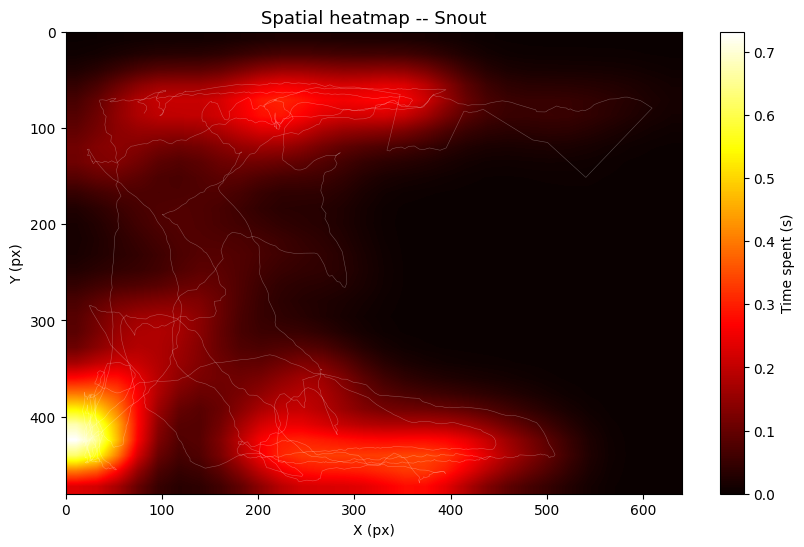

In [93]:
# Build 2D histogram and smooth it
heatmap, _, _ = np.histogram2d(x, y,bins=30,range=[[0, VIDEO_W], [0, VIDEO_H]])
heatmap = gaussian_filter(heatmap.T / FPS, sigma=1.5)  # convert to seconds

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(heatmap,extent=[0, VIDEO_W, VIDEO_H, 0],cmap='hot',aspect='equal',interpolation='bilinear')
plt.colorbar(im, ax=ax, label='Time spent (s)')

ax.plot(x, y, lw=0.4, color='white', alpha=0.3)
ax.set_title(f'Spatial heatmap -- {BODY_PART}', fontsize=13)
ax.set_xlabel('X (px)')
ax.set_ylabel('Y (px)')

plt.show()

## Discussion

This project demonstrates how pose-estimation outputs from DeepLabCut can be transformed into quantitative behavioral metrics.

The workflow illustrates:
- locomotion analysis
- spatial exploration assessment
- velocity estimation
- occupancy mapping

Such approaches can support reproducible and scalable behavioral analysis in neuroscience experiments.